In [13]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# HMA annual time series

In [14]:
iyear=1980
fyear=2023
dom='HMA'

In [15]:
#Run python file : script/compute_timeseries_tp_CHIRPS.py
time_series=pd.read_csv(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/timeseries_tp_annual_{dom}_{iyear}-{fyear}_HARv2.csv')
stats_series=pd.read_csv(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/stats_tp_annual_{dom}_{iyear}-{fyear}_HARv2.csv')

In [16]:
Trend=stats_series.loc[stats_series['stat'] == 'slope', 'value'].values[0]
P_value=stats_series.loc[stats_series['stat'] == 'p_value', 'value'].values[0]
Mean=stats_series.loc[stats_series['stat'] == 'mean', 'value'].values[0]
Std=stats_series.loc[stats_series['stat'] == 'std', 'value'].values[0]
Min=stats_series.loc[stats_series['stat'] == 'min', 'value'].values[0]
Max=stats_series.loc[stats_series['stat'] == 'max', 'value'].values[0]

Trend : -0.01 kg m⁻² / year (p-value = 0.748)
Mean = 58.66 kg m⁻²
Std = 3.22 kg m⁻²
Min = 53.08 kg m⁻²
Max = 67.34 kg m⁻²



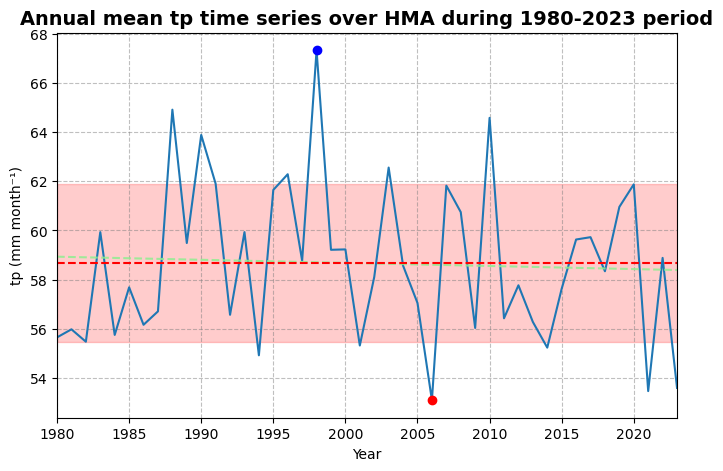

In [17]:
print(f'Trend : {Trend:.2f} kg m⁻² / year (p-value = {P_value:.3f})\n'
    f'Mean = {Mean:.2f} kg m⁻²\n'
    f'Std = {Std:.2f} kg m⁻²\n'
    f'Min = {Min:.2f} kg m⁻²\n'
    f'Max = {Max:.2f} kg m⁻²\n')

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(time_series.iloc[:,0], time_series.iloc[:,1])

ax.plot(time_series.iloc[:,0], time_series.iloc[:,2], linestyle='--', color='lightgreen', alpha=0.85)
ax.axhline(Mean, linestyle='--', color='Red')
ax.fill_between(time_series.iloc[:,0],
                Mean - Std,Mean + Std,
                color='red',alpha=0.2)

# Min et Max
year_min = time_series.iloc[:,0][np.argmin(time_series.iloc[:,1])]
year_max = time_series.iloc[:,0][np.argmax(time_series.iloc[:,1])]
val_min=Min
val_max=Max

ax.scatter(year_min, val_min, zorder=5, color='Red')
ax.scatter(year_max, val_max, zorder=5, color='Blue')

ax.set_xlim(iyear, fyear)

ax.set_xlabel('Year')
ax.set_ylabel('tp (mm month⁻¹)')

ax.set_title(f'Annual mean tp time series over {dom} during {iyear}-{fyear} period', fontsize=14, weight='bold')
ax.grid(linestyle='--', color='gray', alpha=0.5)

plt.show()

# tp season time series

In [18]:
seasons = ['DJFM','AM','JJAS','ON']

time_series_dict = {}
stats_series_dict={}

for season in seasons:
    time_series_dict[season]=pd.read_csv(
        f'/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/timeseries_tp_{season}_{dom}_{iyear}-{fyear}_HARv2.csv')
    stats_series_dict[season]=pd.read_csv(
        f'/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/stats_tp_{season}_{dom}_{iyear}-{fyear}_HARv2.csv')

              DJFM       AM     JJAS      ON
stat                                        
mean        28.398   58.404  104.384  28.226
std          4.399    4.876    7.669   3.769
min         19.036   50.100   89.989  20.182
max         38.418   70.336  123.874  38.751
slope       -0.104   -0.029    0.058   0.029
intercept  235.578  116.690  -10.971 -29.423
r_value     -0.299   -0.076    0.095   0.097
p_value      0.049    0.625    0.538   0.531
std_err      0.051    0.059    0.093   0.046


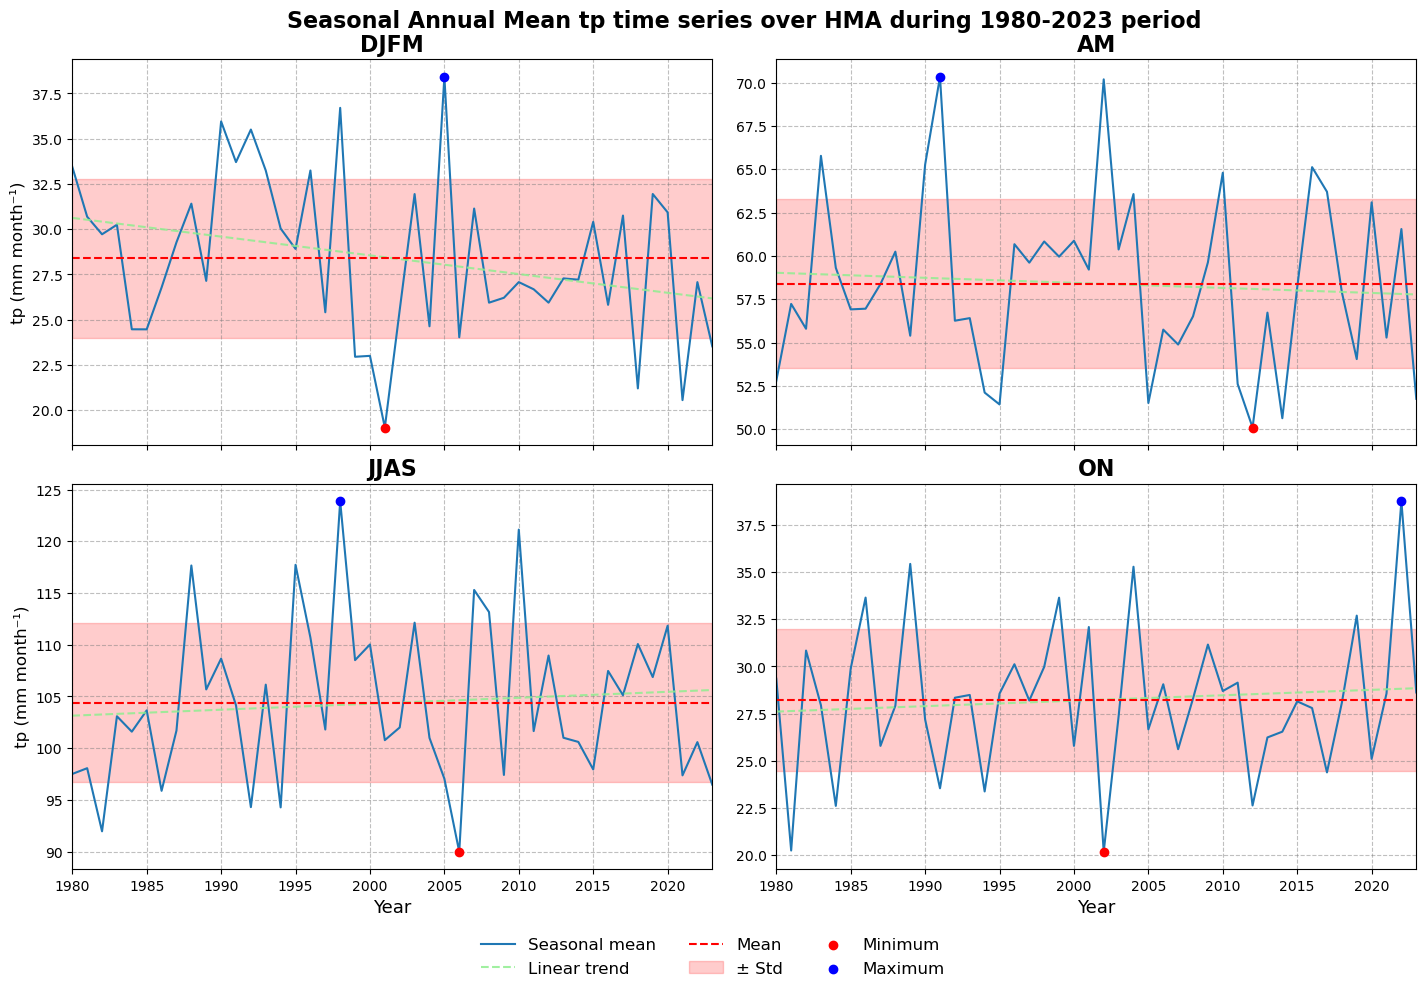

In [19]:
summary = pd.DataFrame({
    season: stats_series_dict[season].set_index('stat')['value']
    for season in seasons
})
print(summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]

    Mean=stats_series_dict[season].loc[stats_series_dict[season]['stat'] == 'mean', 'value'].values[0]
    Std=stats_series_dict[season].loc[stats_series_dict[season]['stat'] == 'std', 'value'].values[0]
    Min=stats_series_dict[season].loc[stats_series_dict[season]['stat'] == 'min', 'value'].values[0]
    Max=stats_series_dict[season].loc[stats_series_dict[season]['stat'] == 'max', 'value'].values[0]
    
    ax.plot(time_series_dict[season].iloc[:,0], time_series_dict[season].iloc[:,1],label='Seasonal mean' if i == 0 else None)
    
    ax.plot(time_series_dict[season].iloc[:,0], time_series_dict[season].iloc[:,2], linestyle='--', color='lightgreen', alpha=0.85,label='Linear trend' if i == 0 else None)
    ax.axhline(Mean, linestyle='--', color='Red', label='Mean' if i == 0 else None)
    ax.fill_between(time_series_dict[season].iloc[:,0],
                    Mean - Std,
                    Mean + Std,
                    color='red',alpha=0.2, label='± Std')
    
    # Min et Max
    year_min = time_series_dict[season].iloc[:,0][np.argmin(time_series_dict[season].iloc[:,1])]
    year_max = time_series_dict[season].iloc[:,0][np.argmax(time_series_dict[season].iloc[:,1])]
    val_min=Min
    val_max=Max
    
    ax.scatter(year_min, val_min, zorder=5, color='Red', label='Minimum' if i == 0 else None)
    ax.scatter(year_max, val_max, zorder=5, color='Blue', label='Maximum' if i == 0 else None)

    if i in [0, 2]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
        ax.tick_params(labelleft=True)
    else:
        ax.tick_params(labelleft=True)  # pas de labels pour colonne droite

    if i in [2, 3]:  # ligne du bas
        ax.set_xlabel('Year', fontsize=13)
        ax.tick_params(labelbottom=True)
    else:
        ax.tick_params(labelbottom=False)  # pas de labels pour ligne du haut
    
    ax.set_title(season, fontsize=16, weight="bold")
    
    ax.set_xlim(iyear, fyear)
    #ax.set_ylim(60,200)
    ax.grid(linestyle='--', color='gray', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,loc='lower center',ncol=3,fontsize=12,frameon=False)

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0.1)
fig.suptitle(f'Seasonal Annual Mean tp time series over {dom} during {iyear}-{fyear} period', fontsize=16, weight='bold')

plt.show()